In [61]:
from nba_api.stats.endpoints import leaguegamefinder
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Pull data from the 2024-2025 NBA season
games_25 = leaguegamefinder.LeagueGameFinder(season_nullable='2024-25', season_type_nullable='Regular Season')
# get data frame from returned list
df_25: pd.DataFrame = games_25.get_data_frames()[0]
# Write data to csv for easier viewing. Not necessary
df_25.to_csv('season_raw_25.csv' ,index=False)


# Pull data from the 2025-2026 NBA season
games_26 = leaguegamefinder.LeagueGameFinder(season_nullable='2025-26', season_type_nullable='Regular Season')
# get data frame from returned list
df_26: pd.DataFrame = games_26.get_data_frames()[0]
# Write data to csv for easier viewing. Not necessary
df_26.to_csv('season_raw_26.csv' ,index=False)

In [62]:
# Keep Only columns that you need for each respective Season
# 2024-25
team_stats_25 = df_25[['SEASON_ID','TEAM_ABBREVIATION', 'WL', 'PTS', 'FG3M']]
# Change Season ID Value
team_stats_25['SEASON_ID'] = '2024-25'
# Write to csv for easy viewing
team_stats_25.to_csv('season_breakdown_25.csv', index=False)

# 2025-26
team_stats_26 = df_26[['SEASON_ID','TEAM_ABBREVIATION', 'WL', 'PTS', 'FG3M']]
# Change Season ID Value
team_stats_26['SEASON_ID'] = '2025-26'
# Write to csv for easy viewing
team_stats_26.to_csv('season_breakdown_26.csv', index=False)

In [63]:
summary_25 = (
    team_stats_25.groupby('TEAM_ABBREVIATION')
    .agg(
        games=('WL', 'count'),
        wins=('WL', lambda s: (s=='W').sum()),
        points=('PTS', 'mean'),
        threes=('FG3M', 'sum') 
    )
).reset_index()

In [64]:
summary_26 = (
    team_stats_26.groupby('TEAM_ABBREVIATION')
    .agg(
        games=('WL', 'count'),
        wins=('WL', lambda s: (s=='W').sum()),
        points=('PTS', 'mean'),
        threes=('FG3M', 'sum') 
    )
).reset_index()

In [65]:
summary_25['SEASON_ID'] = '2024-25'
summary_26['SEASON_ID'] = '2025-26'

summary_25.to_csv('season_agg_25.csv', index=False)
summary_26.to_csv('season_agg_26.csv', index=False)

In [66]:
summary_25.sort_values('TEAM_ABBREVIATION',ascending=False)
summary_26.sort_values('TEAM_ABBREVIATION',ascending=False)

print(summary_25.head())
print(summary_26.head())

# summary = pd.concat([summary_25, summary_26], axis=0)

# summary.sort_values('TEAM_ABBREVIATION',ascending=False)
# print(summary.head())
# summary.to_csv('sum.csv', index=False)

  TEAM_ABBREVIATION  games  wins      points  threes SEASON_ID
0               ATL     82    40  118.182927    1107   2024-25
1               BKN     82    26  105.109756    1113   2024-25
2               BOS     82    61  116.268293    1457   2024-25
3               CHA     82    19  105.097561    1065   2024-25
4               CHI     82    39  117.804878    1266   2024-25
  TEAM_ABBREVIATION  games  wins      points  threes SEASON_ID
0               ATL     82    46  118.463415    1201   2025-26
1               BKN     82    20  105.926829    1073   2025-26
2               BOS     82    56  114.853659    1268   2025-26
3               CHA     82    44  116.012195    1343   2025-26
4               CHI     82    31  116.304878    1169   2025-26


In [67]:
# Query syntax
points_25 = summary.query("SEASON_ID == '2024-25'")['points']
points_26 = summary.query("SEASON_ID == '2025-26'")['points']

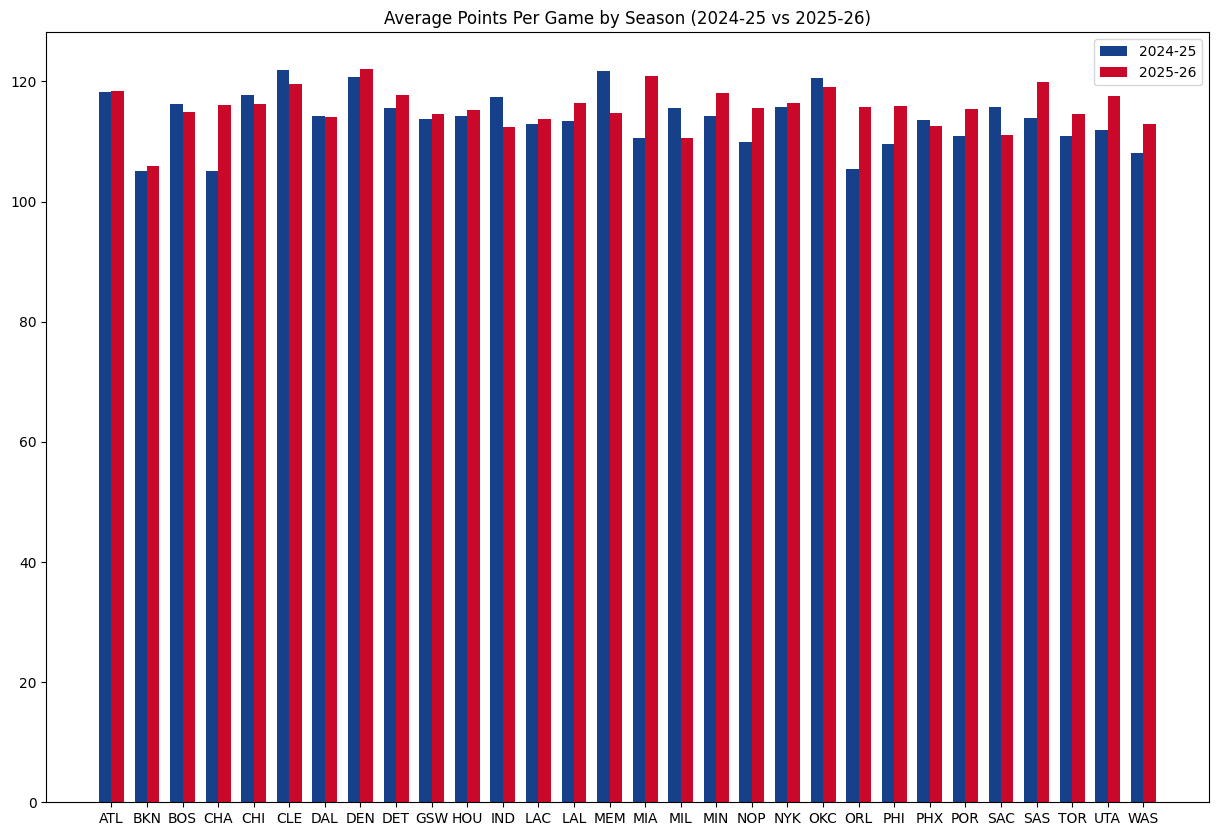

In [87]:
# summary.sort_values('TEAM_ABBREVIATION',ascending=False).plot(
#     x='TEAM_ABBREVIATION', y=[summary.query("SEASON_ID == '2024-25'")['points'], summary.query("SEASON_ID == '2025-26'")['points']], kind='bar',
#     legend=True, figsize=(12,5), title='Average Points Per Game (2024-25 vs 2025-26)'
# )

teams = list(summary_25['TEAM_ABBREVIATION'])
x = np.arange(len(teams))  # Numerical locations for labels
width = 0.35  # Width of each bar

fig, ax = plt.subplots(figsize =(15, 10))
# Shift the first bar left and the second bar right
ax.bar(x - width/2, summary_25['points'], width, label='2024-25', color='#17408B')
ax.bar(x + width/2, summary_26['points'], width, label='2025-26', color='#C9082A')

ax.set_title("Average Points Per Game by Season (2024-25 vs 2025-26)")
ax.set_xticks(x)
ax.set_xticklabels(teams)
ax.legend()
plt.savefig('Avg_Points.png')
plt.show()

# barWidth = 0.25
# fig = plt.subplots(figsize =(12, 8)) 
# plt.bar(summary_25['TEAM_ABBREVIATION'], summary_25['points'], width = barWidth, label = '2024-25')
# plt.bar(summary_26['TEAM_ABBREVIATION'], summary_26['points'], width = barWidth, label = '2025-26')
# plt.ylabel('Points')
# plt.tight_layout()
# plt.legend()
# plt.savefig('Avg_Points.png')
# plt.show()